In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Statistics

A trained model is only ever fit to a *finite* sample, so every quantity we read off it (an accuracy, a learned weight, an estimated mean) is a guess computed from random data and would come out differently on a fresh draw. Statistics is the discipline that quantifies that randomness: it tells us how far a guess typically sits from the truth, when an apparent improvement is real rather than noise, and how confident we are entitled to be. This section develops the three ideas a deep-learning practitioner reaches for most often. We define an *estimator* and the two ways it can be wrong, *bias* and *variance*, and prove the decomposition that ties them together; this single identity is behind the U-curve that governs under- and over-fitting in that section. We then turn to *hypothesis testing*, the framework behind A/B tests and benchmark comparisons, and close with *confidence intervals*, which attach a notion of uncertainty to a point estimate. Throughout we take the true parameter $\theta$ to be a scalar; the vector case is identical with sums of squares replaced by squared norms.

We use the following imports throughout the section, plus plain NumPy as `onp` for the label-shuffling in the permutation test and the resampling in the bootstrap.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
import numpy as onp  # plain NumPy for the permutation test and bootstrap below

## Estimators and Their Quality

### Estimators

An *estimator* is a rule that turns data into a guess for an unknown parameter. Formally, given samples $x_1,\ldots,x_n$ drawn from a distribution governed by a parameter $\theta$, an estimator is a function

$$
\hat\theta_n = \hat f(x_1,\ldots,x_n)
$$

that we hope lands near $\theta$. We have met estimators already: in that section the maximum-likelihood estimate of a Bernoulli probability was the fraction of observed ones, and the maximum-likelihood estimate of a Gaussian mean was the sample average. The key fact is that $\hat\theta_n$ is itself a *random variable*: it depends on the random sample, so it would come out differently on a fresh dataset. Asking whether an estimator is *good* is therefore asking about the distribution of $\hat\theta_n$ over repeated datasets (its *sampling distribution*), and that distribution has two features that matter, its center and its spread.

### Bias and Variance

The first feature is the *center*. The **bias** of $\hat\theta_n$ measures the systematic gap between where the estimator centers and the truth,

$$
\operatorname{Bias}(\hat\theta_n) = \mathbb{E}[\hat\theta_n] - \theta ,
$$

the expectation taken over the random sample. When $\operatorname{Bias}(\hat\theta_n)=0$ for every $\theta$ we call $\hat\theta_n$ *unbiased*: it is right *on average*, even though any single estimate misses. Bias is systematic error at a fixed sample size. It may persist as data grows,
or it may vanish for an asymptotically unbiased estimator; that distinction is
made below.

The second feature is the *spread*. The **variance** measures how much the estimator fluctuates around its own center, with the **standard error** its square root,

$$
\operatorname{Var}(\hat\theta_n) = \mathbb{E}\!\left[(\hat\theta_n - \mathbb{E}[\hat\theta_n])^2\right],
\qquad
\operatorname{se}(\hat\theta_n) = \sqrt{\operatorname{Var}(\hat\theta_n)} .
$$

Note carefully that variance is measured against $\mathbb{E}[\hat\theta_n]$, *not* against the true $\theta$: it captures the noise in the estimator, not its accuracy. the figure makes the two features visible by drawing the sampling distribution for two estimators of the same $\theta$. Bias is the offset of the distribution's center from $\theta$; variance is its width.

![The sampling distribution of an estimator, drawn over many datasets. Bias is the offset of the center $\mathbb{E}\left(\hat\theta\right)$ from the true $\theta$; variance is the spread. Left: low bias, high variance. Right: high bias, low variance. A good estimator wants both small, but usually one is traded for the other.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-sampling-distribution.svg)

### Consistency and Efficiency

Bias and variance describe an estimator at a *fixed* sample size. Two further notions describe how it behaves as data accumulates. An estimator is *asymptotically unbiased* if its bias vanishes in the limit, $\lim_{n\to\infty}\operatorname{Bias}(\hat\theta_n)=0$; many estimators used in practice are biased at finite $n$ but asymptotically unbiased, which is usually good enough. A stronger and more useful guarantee is *consistency*: $\hat\theta_n$ is consistent if it *converges in probability* to $\theta$,

$$
\hat\theta_n \xrightarrow{P} \theta,
\qquad\textrm{i.e.}\qquad
P\bigl(|\hat\theta_n-\theta|>\varepsilon\bigr)\to 0 \quad\textrm{for every } \varepsilon>0 .
$$

Consistency is the formal content of the slogan "more data gets us arbitrarily close to the truth." Its prototype is the *weak law of large numbers*: the sample mean is a consistent estimator of the population mean, a proposition we state and prove below once the bias-variance decomposition supplies the tools. We have also already proved a headline instance: that section established consistency for the maximum-likelihood estimator under its regularity hypotheses. A sufficient condition for consistency in general is that *both* the bias and the variance tend to zero, since then the whole sampling distribution collapses onto $\theta$. (The two limits are independent: an estimator can be asymptotically unbiased yet inconsistent because its variance does not vanish, and its variance can vanish while a persistent bias keeps it inconsistent.)

Finally, among *unbiased* estimators we prefer the one that fluctuates least, and we call it *efficient*: efficiency ranks unbiased estimators by their variance, the smaller the better. There is a hard floor here, and we have met it too: the Cramér--Rao bound of that section places a lower bound on the variance of any unbiased estimator, $1/(n\,I(\theta))$, the inverse Fisher information, and the coin-flip simulation there watched the maximum-likelihood estimator land right on that floor. An estimator attaining the bound is as good as unbiased estimation can be (the precise sense in which the MLE is asymptotically efficient). What this section takes from the bound: once unbiasedness is secured, what remains to minimize is variance, which is exactly the second half of the decomposition we turn to next.

## The Bias-Variance Decomposition

We now have two distinct ways an estimator can be wrong, a systematic offset (bias) and random fluctuation (variance), and a single number that ought to combine them: the *mean squared error*. The MSE is *exactly* the sum of these two contributions, with no cross term.

### Mean Squared Error and the Decomposition

The simplest summary of how far an estimator lands from the truth is the **mean squared error**,

$$
\operatorname{MSE}(\hat\theta_n) = \mathbb{E}\!\left[(\hat\theta_n-\theta)^2\right] .
$$

It is always non-negative, and the smaller it is the closer $\hat\theta_n$ sits to $\theta$ on average. If you have read that section you will recognize it as the squared-error loss, now applied to an estimator rather than a prediction.

**Proposition (bias-variance decomposition).** *For any estimator $\hat\theta_n$ of a fixed parameter $\theta$,*

$$
\operatorname{MSE}(\hat\theta_n) = \operatorname{Bias}(\hat\theta_n)^2 + \operatorname{Var}(\hat\theta_n) .
$$

**Proof.** Abbreviate $\mu = \mathbb{E}[\hat\theta_n]$, the center of the estimator, and add and subtract it inside the square:

$$
\operatorname{MSE}(\hat\theta_n)
 = \mathbb{E}\!\left[(\hat\theta_n - \theta)^2\right]
 = \mathbb{E}\!\left[\bigl((\hat\theta_n - \mu) + (\mu - \theta)\bigr)^2\right].
$$

Expanding the square gives three terms. The first is $\mathbb{E}[(\hat\theta_n-\mu)^2]=\operatorname{Var}(\hat\theta_n)$; the last is $(\mu-\theta)^2=\operatorname{Bias}(\hat\theta_n)^2$, a constant. The middle, cross term *vanishes*, because $\mu-\theta$ is a constant and $\hat\theta_n-\mu$ has mean zero by the definition of $\mu$:

$$
2\,(\mu-\theta)\,\mathbb{E}[\hat\theta_n - \mu]
 = 2\,(\mu-\theta)\,(\mu - \mu) = 0 .
$$

What remains is $\operatorname{Var}(\hat\theta_n)+\operatorname{Bias}(\hat\theta_n)^2$. $\blacksquare$

Because the deviation from the center has mean zero, the systematic part and the fluctuating part of the error never interfere, and the squared error splits into the two pieces of the figure. One immediate payoff is the consistency criterion promised above: if both $\operatorname{Bias}(\hat\theta_n)\to0$ and $\operatorname{Var}(\hat\theta_n)\to0$, then the equation forces $\operatorname{MSE}(\hat\theta_n)\to0$, which implies $\hat\theta_n\xrightarrow{P}\theta$: applying Markov's inequality the equation from that section to the nonnegative random variable $(\hat\theta_n-\theta)^2$ gives $P(|\hat\theta_n-\theta|>\varepsilon) \le \operatorname{MSE}(\hat\theta_n)/\varepsilon^2 \to 0$. (For an unbiased estimator this is Chebyshev's inequality the equation; aiming Markov at $\theta$ directly covers the biased case too. Sharper, exponentially decaying rates come from the concentration inequalities of that section when the data are bounded or sub-Gaussian.)

### The Law of Large Numbers

Assembling the pieces just derived yields the guarantee promised above, the same one that that section invoked to justify Monte Carlo integration.

**Proposition (weak law of large numbers).** *If $x_1,\ldots,x_n$ are i.i.d. with mean $\mu$ and finite variance $\sigma^2$, the sample mean $\bar x_n = \frac1n\sum_{i=1}^n x_i$ converges in probability to $\mu$:*

$$
\bar x_n \xrightarrow{P} \mu ,
\qquad\textrm{indeed}\qquad
P\bigl(|\bar x_n - \mu| > \varepsilon\bigr) \le \frac{\sigma^2}{n\,\varepsilon^2}
\quad\textrm{for every } \varepsilon > 0 .
$$

**Proof.** The sample mean is unbiased, $\mathbb{E}[\bar x_n]=\mu$, by linearity of expectation, and its variance is $\operatorname{Var}(\bar x_n)=\sigma^2/n$ by the variance of a sum of independent variables (that section). By the equation its MSE is therefore $0 + \sigma^2/n$, and the Markov step above turns that into the displayed bound, which vanishes as $n\to\infty$. $\blacksquare$

Finite variance is more than the theorem needs: a finite mean $\mathbb{E}|x_1|<\infty$ already suffices, at the cost of a longer argument [@Wasserman.2013]. In whichever form, this is the law that makes averaging work: it is why a Monte Carlo estimate of an integral converges, why a test-set accuracy estimates the true error rate, and why the empirical loss a model is trained on tracks the expected loss it is meant to minimize.

### The Trade-off and Generalization

Identity the equation also explains the central tension of model fitting, told in full in that section. Read $\hat\theta_n$ as a *fitted model* and $\theta$ as the function we wish it had learned: then *underfitting* is bias (a too-simple model misses systematically, however much data it sees) and *overfitting* is variance (a too-flexible model chases the noise of its particular training set) [@Geman.Bienenstock.Doursat.1992]. As model complexity grows, the squared bias falls while the variance rises, and their sum traces the U of the figure; for prediction the expected test error acquires one more term, $\operatorname{Bias}^2 + \operatorname{Var} + \sigma^2$, where $\sigma^2$ is the *irreducible noise* in the labels, a constant floor that shifts the U upward without moving its minimum. Regularization such as weight decay (that section) trades a little added bias for a large reduction in variance, sliding leftward on the curve to a lower total error. (Heavily overparameterized deep networks can defy this textbook U; the decomposition remains exactly true, and that section reproduces the resulting double-descent curve from scratch.)

![As model complexity grows, squared bias falls and variance rises; their sum, the MSE (test error), is a U-curve with a minimum at the sweet spot.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bias-variance-u-curve.svg)

### The Decomposition in Code

The decomposition is an exact algebraic identity, so it should hold to numerical precision on a concrete example. We first define bias and MSE as the formulas the equation and the equation say: averages over a collection of estimates, against the true parameter.

In [2]:
import numpy as onp
def stat_bias(true_theta, est_theta):  # E[theta_hat] - theta
    return onp.mean(est_theta) - true_theta

def mse(est_theta, true_theta):        # E[(theta_hat - theta)^2]
    return onp.mean(onp.square(est_theta - true_theta))

To exercise these we need the *sampling distribution* itself, not a single dataset: we draw many independent datasets from $\mathcal{N}(\theta,\sigma^2)$, compute the sample mean on each, and collect the resulting estimates. Their spread is the variance and their center the bias.

In [3]:
import numpy as onp
theta_true, sigma = 1.0, 4.0
num_datasets, n = 10000, 30  # 10k datasets, each of n=30 points
samples = onp.random.normal(theta_true, sigma, (num_datasets, n))
theta_hats = samples.mean(axis=1)  # one sample-mean estimate per dataset

Now we read the decomposition off the empirical sampling distribution: the MSE of the estimates around the true $\theta$ should match the squared bias plus the variance of the estimates around their own mean, the two sides of the equation. One detail matters for exactness. The identity is a statement about expectations under a *single* distribution, here the empirical distribution of our $10{,}000$ estimates, whose expectations are plain averages; that dictates the *plug-in* variance that divides by the number of estimates (`ddof=0`, the default in most libraries), not the unbiased $n-1$ variant we meet in the next subsection. With the plug-in choice the proof's algebra goes through verbatim for the empirical averages.

In [4]:
import numpy as onp
bias = stat_bias(theta_true, theta_hats)
# Default ddof=0: the plug-in variance of the estimates, which makes the
# identity exact for empirical averages (the n-1 variant is the next subsection)
var = onp.var(theta_hats)
mse(theta_hats, theta_true), var + onp.square(bias)

(np.float64(0.5284503820141454), np.float64(0.5284503820141454))

The two numbers agree to floating-point round-off (the identity is exact), and both are close to the theoretical value. For the sample mean of $\mathcal{N}(\theta,\sigma^2)$ the bias is exactly zero (the average of unbiased draws is unbiased) and the variance is $\sigma^2/n$ (the variance-of-a-sum result from that section), so $\operatorname{MSE}=\sigma^2/n = 16/30 \approx 0.53$. Because *both* the bias ($0$) and the variance ($\sigma^2/n\to0$) vanish as $n\to\infty$, the sample mean is consistent, exactly as the weak law of large numbers the equation asserts: the simulation is that proposition run in the small.

### Why the Unbiased Variance Divides by $n-1$

The sample mean was unbiased for free. The sample *variance* is more delicate, and it exposes a subtlety that the library's `std` function encodes in a `ddof` flag. Given samples $x_1,\ldots,x_n$ with sample mean $\bar x=\frac1n\sum_i x_i$, the natural estimator of the population variance $\sigma^2$ would average the squared deviations,

$$
s_0^2 = \frac1n\sum_{i=1}^n (x_i-\bar x)^2 .
$$

This is *biased*: it systematically underestimates $\sigma^2$, because the deviations are measured from $\bar x$ (the point that *minimizes* the sum of squared deviations for this particular sample) rather than from the unknown true mean $\mu$. The $n$-divided estimator matters in its own right: $s_0^2$ *is* the maximum-likelihood estimator of a Gaussian's variance, so the bias computed here is precisely the finite-sample bias of the MLE that that section promised when it called maximum likelihood only *asymptotically* unbiased. The fix is to divide by $n-1$ instead of $n$, and the factor is exactly what unbiasedness requires.

**Proposition (unbiased sample variance).** *For i.i.d. samples with variance $\sigma^2$,*

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i-\bar x)^2
\qquad\textrm{satisfies}\qquad
\mathbb{E}[s^2] = \sigma^2 .
$$

**Proof.** Center the data at the true mean $\mu$ by writing $x_i-\bar x = (x_i-\mu)-(\bar x-\mu)$, and expand the sum of squared deviations:

$$
\sum_{i=1}^n (x_i-\bar x)^2
 = \sum_{i=1}^n (x_i-\mu)^2 - n\,(\bar x-\mu)^2 ,
$$

where the cross term collapsed because $\sum_i (x_i-\mu) = n(\bar x-\mu)$. Now take expectations. Each $\mathbb{E}[(x_i-\mu)^2]=\sigma^2$, so the first sum has expectation $n\sigma^2$. The second uses the variance of the sample mean, $\mathbb{E}[(\bar x-\mu)^2]=\operatorname{Var}(\bar x)=\sigma^2/n$, so that term has expectation $n\cdot\sigma^2/n=\sigma^2$. Hence

$$
\mathbb{E}\!\left[\sum_{i=1}^n (x_i-\bar x)^2\right] = n\sigma^2 - \sigma^2 = (n-1)\,\sigma^2 .
$$

Dividing by $n-1$ gives $\mathbb{E}[s^2]=\sigma^2$. $\blacksquare$

The intuition is *degrees of freedom*: estimating $\bar x$ from the same data consumes one degree of freedom, so only $n-1$ of the deviations are free to vary, and dividing by $n-1$ rather than $n$ corrects for it exactly. (As $n\to\infty$ the two estimators agree, so $s_0^2$ is biased but asymptotically unbiased and consistent.) We can watch the bias appear and the correction remove it by estimating both variances over many datasets and averaging.

In [5]:
import numpy as onp
n = 3  # small n makes the 1/n bias glaring; the gap shrinks like 1/n
data = onp.random.normal(0, 2, (100000, n))  # sigma^2 = 4
dev2 = onp.square(data - data.mean(axis=1, keepdims=True)).sum(axis=1)
print('true variance    = 4')
print(f'E[divide by n]   = {float((dev2 / n).mean()):.3f}  (biased)')
print(f'E[divide by n-1] = {float((dev2 / (n - 1)).mean()):.3f}  (unbiased)')

true variance    = 4
E[divide by n]   = 2.666  (biased)
E[divide by n-1] = 3.998  (unbiased)


With $n=3$ the biased estimator averages near $\tfrac{n-1}{n}\sigma^2 = \tfrac23\cdot 4 \approx 2.67$, while dividing by $n-1$ recovers $4$, confirming the equation. The `ddof` argument ("delta degrees of freedom") selects the denominator: `ddof=1` divides by $n-1$, `ddof=0` by $n$.

## Hypothesis Testing

The bias-variance picture asks *how good* a single estimate is. Hypothesis testing asks a different question that dominates experimental practice: given two estimates (a baseline and a new model, a control group and a treatment), is the observed difference *real*, or could it be a fluke of the particular sample? This is the framework behind A/B testing and behind claims that one architecture beats another on a benchmark.

### The Setup: Null, Alternative, and Two Kinds of Error

A *hypothesis test* weighs evidence against a default claim. The **null hypothesis** $H_0$ is that default, typically "there is no effect" (e.g. the new model is no better than the baseline), and the **alternative** $H_A$ is the effect we hope to detect: sometimes the null's outright negation, but often one-sided or otherwise composite, e.g. "the new model is *better*." The asymmetry is deliberate: we never *prove* $H_0$; we either gather enough evidence to *reject* it in favor of $H_A$, or we fail to, much as a court returns "guilty" or "not guilty" rather than "innocent."

Because the data are random, the decision can go wrong in two ways. A **type I error** (false positive) is rejecting $H_0$ when it is in fact true: declaring an effect that is not there. A **type II error** (false negative) is failing to reject $H_0$ when it is in fact false: missing a real effect. Their rates have standard names, the significance level $\alpha$ and $\beta$,

$$
\alpha = P(\textrm{reject } H_0 \mid H_0 \textrm{ true}),
\qquad
\beta = P(\textrm{fail to reject } H_0 \mid H_0 \textrm{ false}),
$$

and the four possible outcomes arrange into the $2\times2$ decision matrix of the figure: rows are whether $H_0$ is true or false, columns are our decision. The diagonal cells are correct; the off-diagonal cells are the two errors. One caveat on the notation: when $H_A$ is composite, "$H_0$ false" does not pin down a single distribution, so $\beta$ (and the power below) is a *function* of the true parameter, evaluated at a given alternative; that is exactly how the figure will draw it.

![The $2\times 2$ hypothesis-test decision matrix: correct decisions on the diagonal, the type I error (rate $\alpha$) and type II error (rate $\beta$) off the diagonal, and the power $1-\beta$ in the correct-rejection cell.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-type-i-ii-matrix.svg)

### Significance and Power

We *choose* the type I error rate up front: the **significance level** $\alpha$ is the risk of a false positive we are willing to tolerate, conventionally $\alpha=0.05$. The complement $1-\alpha$ is the *confidence level*, the name that returns with the confidence intervals below. The bottom-right cell of the matrix is the quantity we want to be large: the **statistical power**

$$
1 - \beta = P(\textrm{reject } H_0 \mid H_0 \textrm{ false})
$$

is the probability the test *detects* a real effect, again evaluated at a given alternative. A test with $\alpha=0.05$ but power $0.2$ rejects a true null only $5\%$ of the time yet still misses $80\%$ of genuine effects of that size: underpowered, and useless for confirming improvements. A common target is $1-\beta=0.8$.

Power is what determines how much data we need, and the simplest test of all makes the accounting explicit. In the one-sample two-sided **$z$-test** the data are Gaussian with *known* variance $\sigma^2$, the null is $H_0\!:\mu=0$, the statistic is $T=\sqrt n\,\bar x/\sigma$, which under $H_0$ is exactly standard normal, and we reject when $|T|\ge z_{1-\alpha/2}$, where $z_q$ denotes the standard-normal quantile ($z_{0.975}\approx1.960$ at $\alpha=0.05$). Now suppose the true mean is some $\mu\neq0$ and write $\delta=|\mu|/\sigma$ for the **standardized effect**, the size of the effect measured in units of the noise. Then $T$ is Gaussian with mean $\pm\delta\sqrt n$ and unit variance, so the test detects the effect with probability $\Phi(\delta\sqrt n - z_{1-\alpha/2})$, where $\Phi$ is the standard-normal c.d.f. (the far tail on the opposite side contributes negligibly). Setting this power equal to $1-\beta$, so that $\delta\sqrt n - z_{1-\alpha/2} = z_{1-\beta}$, and solving for $n$ gives the sample size needed to detect a standardized effect $\delta$ at level $\alpha$ with power $1-\beta$:

$$
n \;=\; \frac{\bigl(z_{1-\alpha/2} + z_{1-\beta}\bigr)^{2}}{\delta^{2}} .
$$

At $\alpha=0.05$ and power $0.8$ we have $z_{0.975}\approx1.960$ and $z_{0.8}\approx0.842$, so $n\approx(2.80)^2/\delta^2 = 7.85/\delta^2$: about $8$ samples suffice for a large effect $\delta=1$, while a tiny effect $\delta=0.01$ needs $78{,}489$. This is the $1/\delta^2$ law with its constant filled in, the formula behind exercise 6, and the reason marginal benchmark gains demand enormous test sets to confirm. the figure traces the whole family of *power curves*: for each effect size $\delta$, the probability of detection climbs from $\alpha$ (a false-positive rate is all a test delivers at $\delta=0$) toward $1$ as $n$ grows, crossing the conventional target $0.8$ at a sample size proportional to $1/\delta^2$.

![Power of the one-sample two-sided $z$-test at $\alpha=0.05$ as a function of the sample size $n$, one curve per effect size $\delta$. Every curve starts near $\alpha$ and climbs toward $1$; the dashed line marks the conventional target $0.8$, reached at a sample size that scales like $1/\delta^2$: about $8$ samples for $\delta=1$ but nearly $80{,}000$ for $\delta=0.01$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-power.svg)

### Test Statistics, $p$-values, and Significance

To run a test we compress the data into a single **test statistic** $T(x)$, a scalar chosen so that extreme values are unlikely under $H_0$; the mean difference between two groups is a natural choice. Under $H_0$ the statistic has a known (often approximately Gaussian) *null distribution*, which is what lets us judge whether an observed value is surprising.

The verdict is delivered by the **$p$-value**: the probability, *computed under $H_0$*, of seeing a statistic at least as extreme as the one we observed. For a two-sided test (the common case, where a deviation in either direction counts as evidence),

$$
p\textrm{-value} = P_{H_0}\bigl(|T(X)| \ge |T(x)|\bigr),
$$

valid when the null distribution is symmetric about $0$; in general the two-sided $p$-value is $2\,\min\{P_{H_0}(T\ge t),\, P_{H_0}(T\le t)\}$, which doubles the smaller tail. The one-sided version uses a single tail. We reject $H_0$ when $p \le \alpha$. Geometrically, the rejection region is the set of statistic values whose $p$-value falls below $\alpha$; the figure shows it for a Gaussian null at $\alpha=0.05$ as the two tails beyond the critical values $\pm 1.96$ (the $z$-test's rejection region $|T|\ge1.96$ from above), together holding $5\%$ of the probability. A statistic landing in those tails would be very unlikely if $H_0$ held, so we reject.

![Statistical significance: under the null distribution, the central region holds probability $1-\alpha$ and the two tails together hold $\alpha$. A test statistic in the tails is unlikely under $H_0$, so we reject it.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-significance.svg)

A persistent warning is in order, because the $p$-value is among the most misread numbers in science [@Wasserstein.Lazar.2016]. It is $P(\textrm{data this extreme}\mid H_0)$, a statement about the data *given* the null; it is *not* $P(H_0\mid\textrm{data})$, the probability the null is true, which would require a prior and Bayes' rule. A large $p$-value does *not* confirm $H_0$; it means only that we failed to detect an effect, possibly because the test was underpowered.

A subtler trap is *multiple testing*. The $\alpha=0.05$ guarantee holds for a *single* pre-specified test; run $m$ of them under a true null (sweeping hyperparameters, comparing across benchmarks, retrying until something "works") and the chance of at least one spurious win is $1-(1-\alpha)^m$, which already exceeds $0.4$ at $m=10$. Reporting only the test that cleared $p\le\alpha$ is *$p$-hacking*, and it is how noise gets published as a result. The simplest guard is the *Bonferroni correction* [@Bonferroni.1936]: to hold the family-wide false-positive rate at $\alpha$, test each of the $m$ hypotheses at the stricter level $\alpha/m$. When $m$ runs into the hundreds or thousands, as in a hyperparameter sweep or a screen of model variants, Bonferroni grows hopelessly conservative, and large-scale practice instead controls the *false discovery rate*, the expected fraction of rejections that are false, via the Benjamini--Hochberg procedure [@Benjamini.Hochberg.1995], which sorts the $m$ $p$-values in increasing order and rejects the $k$ smallest, with $k$ the largest index satisfying $p_{(k)}\le k\alpha/m$.

To summarize, a hypothesis test proceeds in five steps:

1. State $H_0$ and $H_A$.
2. Fix the significance level $\alpha$ and a target power $1-\beta$ (which, with the expected effect size, sets the sample size).
3. Collect the data.
4. Compute the test statistic and its $p$-value under $H_0$.
5. Reject $H_0$ if $p \le \alpha$; otherwise fail to reject.

### A Worked Test: Comparing Two Models

Let us walk through the five steps once, on the comparison practitioners face most often: is model B really better than model A, or did it just draw lucky seeds? We simulate per-seed test accuracies for the two models: twenty training runs each, with a true gap of $0.8\%$ buried in seed-to-seed noise of comparable size. Step 1: $H_0$ is that the two models are equally good, i.e. the two accuracy samples come from the same distribution, and $H_A$ is that they differ; step 2: $\alpha=0.05$. The test statistic is the gap between the mean accuracies. Rather than assume a Gaussian null distribution, we use a **permutation test** [@Fisher.1935], which manufactures the null distribution from the data itself: if $H_0$ holds, the labels "A" and "B" carry no information (the $40$ numbers are *exchangeable*), so shuffling the labels and recomputing the gap, many times over, shows exactly how large a gap arises by pure chance. The two-sided $p$-value is the fraction of shuffles producing a gap at least as extreme as the observed one (counting the observed labeling itself among them, which keeps the estimate valid and never exactly zero).

observed gap        = 0.0073
permutation p-value = 0.0197


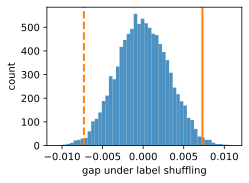

In [6]:
rng = onp.random.default_rng(1)
num_seeds = 20                               # 20 training runs per model
acc_a = rng.normal(0.850, 0.010, num_seeds)  # per-seed accuracy, model A
acc_b = rng.normal(0.858, 0.010, num_seeds)  # model B: a real +0.008 gap
observed = acc_b.mean() - acc_a.mean()       # test statistic: gap in means

pooled = onp.concatenate([acc_a, acc_b])     # under H_0 the labels are arbitrary
B = 10000
gaps = onp.empty(B)
for b in range(B):
    perm = rng.permutation(pooled)           # shuffle the model labels
    gaps[b] = perm[num_seeds:].mean() - perm[:num_seeds].mean()
p_value = (1 + (onp.abs(gaps) >= abs(observed)).sum()) / (B + 1)  # two-sided
print(f'observed gap        = {observed:.4f}')
print(f'permutation p-value = {p_value:.4f}')

d2l.set_figsize()
d2l.plt.hist(gaps, bins=50, color='#1f77b4', alpha=0.8)
d2l.plt.axvline(observed, color='#ff7f0e', lw=2)      # the observed gap
d2l.plt.axvline(-observed, color='#ff7f0e', lw=2, ls='--')
d2l.plt.xlabel('gap under label shuffling')
d2l.plt.ylabel('count');

The observed gap is $0.0073$ (model B looks better by about three quarters of an accuracy point), and only about $2\%$ of label shuffles produce a gap that large, so $p \approx 0.02 \le \alpha = 0.05$ and we reject $H_0$: the improvement is unlikely to be a fluke. The histogram of shuffled gaps makes the verdict visual: they pile up in a bell around zero (no Gaussian assumption put it there; the bell is the *finite-population* central limit theorem for means drawn without replacement from the pooled forty numbers, a relative of the i.i.d. CLT of that section), while the observed gap (solid line) sits far out in the right tail, with only a sliver of the null mass beyond the two lines that the two-sided test counts. Note how close the call is, though. A *real* $0.8\%$ improvement, measured over twenty seeds, only just clears the bar, the power discussion above in action; with five seeds (a common budget) the same gap would usually go undetected. The permutation test assumes no Gaussian shape and works for any statistic we care to compute on the two groups; the same resample-and-recompute idea returns in the bootstrap below.

One refinement matters in practice. When the comparison is *paired*, with models A and B trained and evaluated on the *same* seeds, the exchangeable objects are not the $40$ pooled numbers but the per-seed *differences*, and the right test flips the sign of each difference at random: the paired, or sign-flip, permutation test. It respects the pairing and typically gains power.

## Confidence Intervals

A point estimate $\hat\theta$ carries no notion of uncertainty: it is a single number that hides how much it would wobble on fresh data. A **confidence interval** repairs this by reporting an *interval* engineered to contain the true $\theta$ with high probability. The idea is due to Jerzy Neyman [@Neyman.1937].

### Definition and Interpretation

A confidence interval for $\theta$ is an interval $C_n$ computed from the data such that

$$
P_\theta(C_n \ni \theta) \ge 1 - \alpha \quad \textrm{for all } \theta,
$$

where $1-\alpha$ is the *confidence level* or *coverage*. We write $C_n \ni \theta$ rather than $\theta \in C_n$ to stress where the randomness lives: $\theta$ is a *fixed* unknown, and it is the *interval* $C_n$ that is random, redrawn with every dataset.

This makes the correct interpretation subtle. A $95\%$ confidence interval does *not* mean "the true $\theta$ lies in this particular interval with probability $95\%$": that particular interval is already drawn, and $\theta$ either is or is not inside it. The right reading is *about the procedure*: if we generated many intervals this way, $95\%$ of them would contain $\theta$. The guarantee is on the long-run hit rate of the procedure, not on any single interval. the figure draws the reading literally: one hundred intervals from one hundred independent datasets, almost all trapping the fixed truth, a handful missing; nothing about any single interval announces which kind it is. This frequentist guarantee should not be confused with the Bayesian *credible interval*, which treats $\theta$ itself as random with a prior (the machinery behind MAP estimation in that section) and therefore *can* assert "$\theta$ lies in this particular interval with probability $95\%$," at the price of that probability depending on the chosen prior. For the Beta posterior of that section, for instance, a $95\%$ credible interval for a coin's bias is read directly off the posterior's quantiles ($2.5\%$ and $97.5\%$ of $\mathrm{Beta}(\alpha+x,\ \beta+n-x)$), with no sampling-distribution argument needed.

![One hundred $95\%$ confidence intervals, each computed from its own independent dataset, plotted against the fixed true mean (dashed line). Most intervals trap the truth; the orange ones miss. The $95\%$ guarantee is a statement about this long-run hit rate of the procedure, not about any single interval; a given interval carries no marker of whether it traps the truth.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-coverage.svg)

### A Gaussian Example

The classic case is the mean of a Gaussian $\mathcal{N}(\mu,\sigma^2)$ with both parameters unknown. From $n$ samples we form the usual estimators $\hat\mu_n=\frac1n\sum_i x_i$ and the unbiased $\hat\sigma_n^2=\frac1{n-1}\sum_i (x_i-\hat\mu_n)^2$ from the equation. The *studentized* statistic, centered and scaled by the *estimated* standard error $\hat\sigma_n/\sqrt n$ in place of the unknown true one,

$$
T = \frac{\hat\mu_n - \mu}{\hat\sigma_n/\sqrt n} ,
$$

follows *Student's $t$-distribution* on $n-1$ degrees of freedom [@Student.1908], a fact we take on faith here; the distribution itself is constructed in that section. As $n\to\infty$ the $t$-distribution approaches a standard Gaussian, and the attribution of that limit matters. For Gaussian data the numerator $\hat\mu_n-\mu$ is *exactly* Gaussian at every $n$; the limit comes from the denominator, since $\hat\sigma_n$ is consistent for $\sigma$ (the law of large numbers the equation again, applied to squared deviations) and replacing a factor that converges in probability to a constant leaves a limiting distribution unchanged (*Slutsky's theorem*, also taken on faith [@Wasserman.2013]). The *central limit theorem* of that section enters for *non-Gaussian* data: it makes the sampling distribution of the mean asymptotically Gaussian anyway, so the interval below remains asymptotically valid for the mean of any finite-variance distribution, which is why it gets used so freely in practice. For large $n$, then, $T$ lands in $[-1.96, 1.96]$ with probability $\approx95\%$ (the Gaussian's central $95\%$): exactly $95\%$ in the Gaussian limit, and slightly *less* at finite $n$, where the exact $t$-distribution has heavier tails and one should use the wider $t$-quantile in its place. Rearranging $-1.96 \le T \le 1.96$ for $\mu$ yields the interval

$$
\left[\hat\mu_n - 1.96\,\frac{\hat\sigma_n}{\sqrt n},\; \hat\mu_n + 1.96\,\frac{\hat\sigma_n}{\sqrt n}\right].
$$

This is one of the most-used formulas in statistics. The half-width $1.96\,\hat\sigma_n/\sqrt n$ shrinks like $1/\sqrt n$: to halve the interval we need *four times* the data. Let us construct one for a standard-normal sample, taking the asymptotic $t_\star=1.96$.

In [7]:
import numpy as onp
N = 1000
samples = onp.random.normal(loc=0, scale=1, size=(N,))
t_star = 1.96  # asymptotic value; small N would look this up in a t-table
mu_hat = onp.mean(samples)
se = samples.std(ddof=1) / onp.sqrt(N)  # ddof=1: unbiased sigma_hat
(mu_hat - t_star * se, mu_hat + t_star * se)

(np.float64(-0.059154483584664394), np.float64(0.06315527195971658))

The interval is narrow and brackets the true mean $0$, as it should roughly $95\%$ of the time. The same $1/\sqrt n$ scaling shows up everywhere uncertainty is reported (error bars on a learning curve, the spread of accuracies across random seeds), and the equation is the formula behind them.

"Roughly $95\%$ of the time" is the Neyman guarantee the equation, and we can audit it. The cell below repeats the whole procedure one thousand times: draw a fresh dataset, build the interval the equation, and check whether it traps the true mean. The hit count should land near $950$.

In [8]:
rng = onp.random.default_rng(0)
mu, n, trials = 0.0, 100, 1000
data = rng.normal(mu, 1.0, (trials, n))           # one row = one fresh dataset
mu_hat = data.mean(axis=1)
se = data.std(axis=1, ddof=1) / onp.sqrt(n)
hits = (onp.abs(mu_hat - mu) <= 1.96 * se)        # interval traps the truth?
print(f'{hits.sum()} of {trials} intervals contain the true mean '
      f'(expected about {0.95 * trials:.0f})')

937 of 1000 intervals contain the true mean (expected about 950)


This run counts $937$ hits. Its true target is in fact $\approx947$ rather than $950$: at $n=100$ the exact $t$-quantile is a touch wider than $1.96$, the finite-$n$ effect noted above, so the procedure's true coverage here is $94.7\%$. The printed $937$ sits $1.4$ standard deviations below that target (the count is binomial with standard deviation $\approx7$), well within sampling noise. This is the coverage-strip picture of the figure rendered as a count, and it is the only sense in which any confidence interval is ever "$95\%$ sure."

**Propagating error bars: the delta method.** Often the number we report is not $\hat\theta$ itself but a smooth function of it: the log-odds of an accuracy, the ratio of two losses, a percentage change. A first-order Taylor expansion, $g(\hat\theta)\approx g(\theta)+g'(\theta)\,(\hat\theta-\theta)$, says the fluctuation of $g(\hat\theta)$ is the fluctuation of $\hat\theta$ scaled by the local slope, so standard errors propagate as

$$
\operatorname{se}\bigl(g(\hat\theta)\bigr) \;\approx\; \bigl|g'(\hat\theta)\bigr|\,\operatorname{se}(\hat\theta),
$$

the *delta method* [@Wasserman.2013]. For instance, an accuracy of $\hat p=0.90$ measured on $n=1{,}000$ test examples has $\operatorname{se}(\hat p)=\sqrt{\hat p(1-\hat p)/n}\approx 0.0095$; reporting the log-odds $g(\hat p)=\log\frac{\hat p}{1-\hat p}$ instead, the slope $g'(\hat p)=1/(\hat p(1-\hat p))\approx 11.1$ stretches the error bar to $\approx 0.105$ on the log-odds scale. The same rule with a gradient in place of $g'$ handles vector parameters, and when no derivative is convenient the bootstrap below sidesteps the calculus entirely.

### The Bootstrap

The Gaussian interval the equation rests on a special feature of the mean: its sampling distribution is known, so its standard error has a closed form, $\hat\sigma_n/\sqrt n$. Most quantities a practitioner actually cares about have no such formula. What is the standard error of a *median*, a *correlation*, a model's *test accuracy*, its *AUC* (the area under the ROC curve: the probability that a random positive example is scored above a random negative one) or its *BLEU* score (the sequence-overlap metric of that section)? These are complicated functions of the data with no textbook sampling distribution, and writing down their standard error analytically ranges from painful to impossible.

The **bootstrap**, introduced by Bradley Efron [@Efron.1979], escapes this with a single substitution. We never had access to the true distribution $F$ that generated our $n$ data points; if we did, we could simulate the sampling distribution of a chosen statistic
by drawing fresh datasets from $F$ and recomputing it. The bootstrap's move, the **plug-in principle**, is to substitute the *empirical* distribution $\hat F_n$, which puts mass $1/n$ on each observed point, for the unknown $F$. Drawing $n$ points from $\hat F_n$ is exactly *resampling our own data $n$ times with replacement*. Concretely:

1. From the original sample of size $n$, draw $n$ points **with replacement** to form a *bootstrap resample*; some points appear several times, others not at all.
2. Compute the statistic $\hat\theta^*$ on the resample.
3. Repeat $B$ times to obtain $\hat\theta^*_1,\ldots,\hat\theta^*_B$.

The spread of these $B$ replicates approximates the sampling distribution of $\hat\theta$, so their standard deviation estimates its standard error, and the $\alpha/2$ and $1-\alpha/2$ empirical percentiles of $\{\hat\theta^*_b\}$ form a *percentile* confidence interval. How many replicates? A few hundred ($B\approx200$) suffice for a standard error, but the percentile interval rests on estimated tail quantiles, so use $B$ of at least $1{,}000$--$2{,}000$; resampling is cheap, and below we simply take $B=10{,}000$. the figure shows the construction: one original sample fans out into many resamples, whose statistics pile up into a histogram standing in for the true (unknowable) sampling distribution, with the central band cut off at those percentiles. Two caveats matter. This resampling distribution is *centered at
$\hat\theta$, not at $\theta$*; the bootstrap estimates shape and width from
the one sample we have. It also is not valid for every statistic or sampling
scheme. Ordinary iid bootstrap theory works well for many smooth statistics,
but extrema, parameters on a boundary, very small samples, and nonsmooth or
non-identifiable problems can fail; dependent observations require block,
cluster, or other structure-preserving resampling. Exercise 1 shows the classic
failure for a sample maximum.

![The bootstrap. From a single observed sample (top) we draw many resamples of the same size *with replacement* (middle); recomputing the statistic $\hat\theta$ on each gives the replicates $\hat\theta^\ast_b$, whose histogram (bottom) approximates the sampling distribution. Its spread estimates the standard error, and the central $1-\alpha$ percentile band is a confidence interval. The resampling distribution is centered at $\hat\theta$, the dashed estimate, rather than at the unknown true $\theta$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bootstrap.svg)

Let us bootstrap a statistic with no closed-form standard error, the **median**, from a skewed sample, and contrast it with the Gaussian machinery. We index the data with a matrix of random positions to draw $B$ resamples at once.

In [9]:
rng = onp.random.default_rng(0)
data = rng.exponential(scale=1.0, size=200)  # skewed: median != mean, no SE formula
n = len(data)
theta_hat = onp.median(data)                 # statistic of interest

B = 10000                                     # number of bootstrap resamples
idx = rng.integers(0, n, size=(B, n))         # n positions per resample, WITH replacement
boot = onp.median(data[idx], axis=1)          # one median per resample

se_boot = boot.std(ddof=1)                    # bootstrap standard error of the median
ci_pct = onp.percentile(boot, [2.5, 97.5])    # percentile 95% CI -- no formula needed
print(f'sample median        = {theta_hat:.3f}')
print(f'bootstrap SE         = {se_boot:.3f}')
print(f'percentile 95% CI    = ({ci_pct[0]:.3f}, {ci_pct[1]:.3f})')

sample median        = 0.808
bootstrap SE         = 0.072
percentile 95% CI    = (0.682, 0.955)


The bootstrap hands us a standard error and an interval for the median directly,
without deriving its sampling distribution in closed form; its validity still
rests on the regularity and iid-sampling conditions just stated. For contrast, the Gaussian formula the equation only knows how to handle the *mean*, a different target, which on this skewed data sits well above the median.

In [10]:
mu_hat = data.mean()
se_mean = data.std(ddof=1) / n**0.5           # closed-form SE, but only for the mean
ci_gauss = (mu_hat - 1.96 * se_mean, mu_hat + 1.96 * se_mean)
print(f'Gaussian 95% CI (mean) = ({ci_gauss[0]:.3f}, {ci_gauss[1]:.3f})')

Gaussian 95% CI (mean) = (0.986, 1.272)


The two intervals answer different questions and do not overlap, a direct consequence of the skew. The percentile interval for the median is also slightly *asymmetric* about $\hat\theta$: it inherits the shape of the resampling distribution rather than forcing the symmetric $\pm 1.96\,\widehat{\operatorname{se}}$ of a Gaussian. This is exactly why the bootstrap is so widely used in machine learning: error bars on a held-out accuracy, an AUC, or a BLEU score have no closed-form standard error, but resampling the test set delivers one in a few lines [@Efron.Hastie.2016]; that section does exactly this, putting a bootstrap error bar on its MNIST classifier's test accuracy.

## Summary

* An *estimator* $\hat\theta_n$ is a function of the data; being random, it has a *sampling distribution* whose center and spread are summarized by *bias* $\mathbb{E}[\hat\theta_n]-\theta$ and *variance*. *Consistency* ($\hat\theta_n\xrightarrow{P}\theta$) follows when both shrink with $n$; the *weak law of large numbers* the equation is the sample-mean case; *efficiency* ranks unbiased estimators by their variance.
* The *bias-variance decomposition* $\operatorname{MSE}(\hat\theta_n)=\operatorname{Bias}(\hat\theta_n)^2+\operatorname{Var}(\hat\theta_n)$ splits the error exactly because, after centering at $\mathbb{E}[\hat\theta_n]$, the cross term vanishes. This is the same U-curve as the under/overfitting trade-off (expected test error adds an irreducible noise floor $\sigma^2$), and it explains why regularization trades bias for variance.
* The unbiased sample variance divides by $n-1$, not $n$: estimating the mean from the same data costs one degree of freedom, and the $1/(n-1)$ factor corrects the resulting bias exactly.
* *Hypothesis testing* weighs evidence against a null $H_0$ via a test statistic and its $p$-value $P_{H_0}(\textrm{data this extreme})$; we control the type I error rate $\alpha$ and want high power $1-\beta$. A $p$-value is not $P(H_0\mid\textrm{data})$. A *permutation test* builds the null distribution by shuffling group labels, with no Gaussian assumptions; under many tests, control the family-wise error rate (Bonferroni) or the false discovery rate (Benjamini--Hochberg).
* A *confidence interval* contains $\theta$ with probability $\ge 1-\alpha$ over repeated datasets; the Gaussian interval $\hat\mu_n \pm 1.96\,\hat\sigma_n/\sqrt n$, exact for Gaussian data in the large-$n$ limit and extended to other data by the *central limit theorem*, has half-width shrinking like $1/\sqrt n$.
* The ordinary iid *bootstrap* estimates the sampling distribution of many
  regular statistics with no convenient closed-form standard error (a median,
  an accuracy, an AUC) by resampling observations with replacement. It can fail
  for extrema, boundaries, and nonregular statistics, and dependent data need a
  resampling scheme that preserves their structure.

## Exercises

1. Let $X_1, \ldots, X_n \overset{\textrm{iid}}{\sim} \textrm{Unif}(0,\theta)$ and consider the estimators $\hat\theta = \max\{X_1,\ldots,X_n\}$ and $\tilde\theta = \frac2n\sum_i X_i$. Find the bias, variance, and MSE of each, and decide which is better. Is $\hat\theta$ biased? Is it consistent? Finally, try to bootstrap a confidence interval for $\theta$ from $\hat\theta=\max_i X_i$ and explain why it is poor: with what probability does a bootstrap resample contain the largest observation, so that $\hat\theta^* = \hat\theta$ exactly? (This is the classic example where the bootstrap fails: the true sampling distribution of $\hat\theta$ lives entirely below $\theta$, while the resampling distribution puts a large point mass exactly at $\hat\theta$.)
2. Prove the bias-variance decomposition the equation directly by expanding $\mathbb{E}[(\hat\theta_n-\theta)^2]$ into $\mathbb{E}[\hat\theta_n^2]-2\theta\,\mathbb{E}[\hat\theta_n]+\theta^2$ and substituting $\mathbb{E}[\hat\theta_n^2]=\operatorname{Var}(\hat\theta_n)+\mathbb{E}[\hat\theta_n]^2$. Confirm it agrees with the add-and-subtract proof in the text.
3. The decomposition check computes the variance of the $10{,}000$ estimates with the plug-in estimator (`ddof=0`). Rerun it with the unbiased estimator (`ddof=1`) and compare the two sides of the equation again. Which variance estimator makes the identity exact to floating-point precision, and why? (Hint: the empirical distribution's expectations are plain averages; which denominator does that force?)
4. Shrink the per-dataset size $n$ in the sampling-distribution simulation and confirm the spread of $\hat\theta$ widens like $\sigma/\sqrt n$. Repeat with the biased estimator $\hat\theta=\max_i X_i$ for $\textrm{Unif}(0,\theta)$ and watch the center shift away from $\theta$.
5. A test reports $p = 0.5$. Is this evidence that $H_0$ is true? Explain in terms of $P(\textrm{data}\mid H_0)$ versus $P(H_0\mid\textrm{data})$, and describe a situation where a large $p$-value reflects only low power.
6. Using the $1/(\textrm{effect size})^2$ scaling, estimate how many times more samples are needed to detect an effect of size $0.1$ than one of size $0.5$ at the same $\alpha$ and power.
7. Run the confidence-interval code with $N=2$ and $\alpha=0.5$ (so $t_\star=1.0$) for $100$ independently generated datasets, and look at the resulting intervals. Some are extremely short and far from the true mean $0$. Does this contradict the $1-\alpha$ coverage guarantee? Would you trust a short interval as a sign of a precise estimate?
8. Modify the bootstrap code to target the *mean* instead of the median. Compare the bootstrap standard error and percentile interval against the closed-form Gaussian results $\hat\sigma_n/\sqrt n$ and the equation on the same sample. Do they roughly agree? Why should they, given the central limit theorem?
9. Suppose you compare $m=20$ models against a baseline, all in truth no better, each with an independent test at $\alpha=0.05$. What is the probability that at least one clears $p\le 0.05$ by chance? Recompute the per-test threshold the Bonferroni correction prescribes to hold the family-wide false-positive rate at $0.05$, and verify it brings the spurious-win probability back near $0.05$.

[Discussions](https://d2l.discourse.group/t/1102)